# Tutorial on the modified versions of the same signal

In this tutorial, we simulate the same system than in validation/PUMA_simulation.ipynb.
It corresponds to the systems used in *Programmable Ultrasensitive Molecular Amplifier for Digital and
Multiplex MicroRNA Quantification. MicroRNA Detection and Target Identification*, Rondelez, Ginès.

In this system, the converter template produces alpha in a version with a shortened 5' end but an elongated 3' end.
We refer to this version as alpha+2-2.

Then, we alpha+2-2 is converted into the full version alpha by aT, the elongated part on the 3' end is cleaved, leading to the version alpha-2.
Therefore, we have here three versions of the same signal strand: alpha, alpha+2-2, and alpha-2.

alpha-2 is automatically created during the simulation, there is no need to declare it.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Get the absolute path to the root directory
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)


from PEN_simulation import PEN_System
from strands import Signal, Drain, Template, Reporter, reverse_complement


In [2]:
def detection_system(
    temperature=45,
    leak=3e-8,
    BsmI_conc=400,
    NBI_conc=10,
    pol_conc=30,
    exo_conc=23,
    target_conc=0,
    alpha_conc=0,
    cT_conc=0,
    dT_conc=0,
    aT_conc=0,
    rT_conc=0,
    leak_aT=None,
    leak_cT=None,
    ):

    system = PEN_System(temperature=temperature,
                        concentration_BsmI=BsmI_conc,
                        concentration_NBI=NBI_conc,
                        concentration_pol=pol_conc,
                        concentration_exo=exo_conc,
                        leak=leak)

    # Define the Triggers
    alpha=Signal(name="alpha", 
                 sequence="CATTCAGGATCG", 
                 concentration=alpha_conc,
                 protected=False, 
                 IsDrained=True, 
                 plus=0)
    
    # Version corresponding to alpha+2-2, produced by the converter template, with an elongated 3' end and a shortened 5' end
    alpha_p2m2=Signal(name="alpha", 
                      sequence="TTCAGGATCGCA", 
                      concentration=0, 
                      protected=False, 
                      IsDrained=True, 
                      plus=2,
                      minus=2)
    
    

    target=Signal(name="target",
               sequence="AGGTTGGGATCGGTTGCAATGCT", 
               concentration=target_conc, 
               protected=False, 
               IsDrained=True)
    system.add_signal(alpha)
    system.add_signal(target)
    system.add_signal(alpha_p2m2)
    # system.add_signal(alpha_m2)

    # Define the Templates
    aT = Template(name="aT", 
                  sequence="CGATCCTGAATGCGATCCTGAA", 
                  input=alpha, 
                  output=alpha, 
                  concentration=aT_conc, 
                  nick="BsmI", 
                  protected=True, 
                  irreversible=False, 
                  phosphorylated=True, 
                  leak=leak_aT)
    
    cT = Template(name="cT", 
                  sequence="TGCGATCCTGAAGTTTGACTCAAGCATTGCAACCGATCCCAACCT", 
                  input=target, 
                  output=alpha_p2m2, 
                  concentration=cT_conc, 
                  nick="NBI", 
                  protected=True, 
                  irreversible=True, 
                  leak=leak_cT)
    
    system.add_template(aT)
    system.add_template(cT)

    # Define the dT template
    pT = Drain(name="pT", 
               input=alpha, 
               concentration=dT_conc, 
               sequence= "TTTTTCGATCCTGAATG", 
               protected=True)
    system.add_drain(pT)

    # Define the reporter template
    rT_output = Signal(name="rT_output", 
                       sequence="CATTCAGAAT", 
                       concentration=0, 
                       protected=False, 
                       IsDrained=False)
    system.add_signal(rT_output)
    rT_alpha = Reporter(name="rTalpha", 
                        input=alpha, 
                        fluorophore="Atto633", 
                        quencher="BHQ1", 
                        sequence="ATTCAGAATGCGATCCTGAAT", 
                        concentration=rT_conc, 
                        reversible=True, 
                        output=rT_output)
    system.add_reporter(rT_alpha)

    
    return system

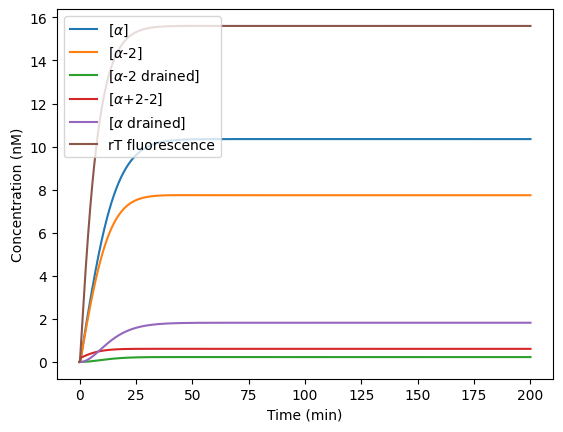

In [3]:
system=detection_system(target_conc=100, cT_conc=5, aT_conc=20, dT_conc=5, rT_conc=50, leak_aT=6e-7, leak_cT=5e-7, temperature=50)
from scipy.integrate import odeint


# Define time of the simulation
t=np.linspace(0,200,10001)

y=system.solve_system(t)

fluo=system.fluorescence_list(y, "rTalpha")

alphap2m2_concentrations=system.concentration_list(y,"alpha", option="alone", plus=2, minus=2)       # extract the solution corresponding to alpha
alpham2_concentrations=system.concentration_list(y,"alpha", option="alone", plus=0, minus=2)       # extract the solution corresponding to alpha
alpham2_drained_concentrations=system.concentration_list(y,"alpha", option="drained", plus=0, minus=2)       # extract the solution corresponding to alpha
alpha_concentrations=system.concentration_list(y,"alpha", option="alone", plus=0, minus=0)       # extract the solution corresponding to alpha
alpha_drained_concentrations=system.concentration_list(y,"alpha", option="drained", plus=0, minus=0)       # extract the solution corresponding to alpha

plt.plot(t,alpha_concentrations, label=r"[$\alpha$]")
plt.plot(t,alpham2_concentrations, label=r"[$\alpha$-2]")
plt.plot(t,alpham2_drained_concentrations, label=r"[$\alpha$-2 drained]")
plt.plot(t,alphap2m2_concentrations, label=r"[$\alpha$+2-2]")
plt.plot(t,alpha_drained_concentrations, label=r"[$\alpha$ drained]")
plt.plot(t,fluo, label="rT fluorescence")


plt.legend()
plt.xlabel("Time (min)")
plt.ylabel("Concentration (nM)")
plt.show()

PEN System Summary
Temperature: 50 °C
Leak rate: 3e-08
Sodium concentration: 0.07 M
Magnesium concentration: 0.0125 M

--------------------------------------------------
Enzyme Concentrations:
  Nb.BsmI concentration: 400 U/µL
  Nt.BstNBI concentration: 10 U/µL
  Polymerase concentration: 30 U/µL
  Exonuclease concentration: 23 nM


--------------------------------------------------
Kinetic Rates Dictionary
--------------------------------------------------
alpha           <-> aT              (input) : k_on = 8.90e-01 nM⁻¹·min⁻¹, k_off = 5.58e+03 min⁻¹
alpha           <-> aT              (output) : k_on = 5.86e-01 nM⁻¹·min⁻¹, k_off = 5.93e+02 min⁻¹
alpha           <-> pT              : k_on = 5.86e-01 nM⁻¹·min⁻¹, k_off = 5.93e+02 min⁻¹
alpha           <-> rTalpha         : k_on = 8.21e-01 nM⁻¹·min⁻¹, k_off = 2.36e+03 min⁻¹
target          <-> cT              : k_on = 9.90e-01 nM⁻¹·min⁻¹, k_off = 2.50e-06 min⁻¹
alpha           <-> cT              : k_on = 8.68e-01 nM⁻¹·min⁻¹, k_off = 5.

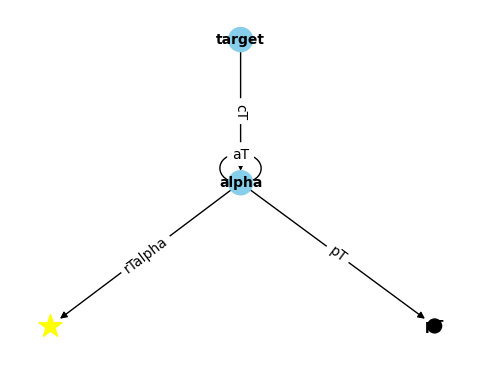

In [4]:
system.print(detailed_kinetics=True, enzymes_kinetic=True)
system.graph_representation(size=0.3, label=True)

We can follow the concentration of each version of the same signal. The binding between alpha+2-2 and aT is very favorable, and since [cT] is low, its concentration stays low.
Once in solution alpha-2 behaves as alpha with aT, as aT is 3' shortened. Since alpha-2 is less compatible with dT than alpha, its concentration stays quite high compared with the one of alpha.